# Clase 5 — Agente con Tools sobre datos biomedicos

## Parte 1-B: Agente con Tool-Use

---

### Diferencia con el enfoque RAG

| | RAG Vectorial | Tool-Use Agent (este notebook) |
|---|---|---|
| **Como accede a los datos** | Embeddings + cosine similarity | El LLM decide que tool llamar |
| **Quien elige que info usar** | El retriever (mecanico) | El LLM (razona sobre que necesita) |
| **Ventaja** | Rapido, no depende del LLM para buscar | Mas flexible, puede combinar tools |
| **Desventaja** | Limitado a similitud semantica | Mas lento, usa mas tokens |

### Que es un agente con tools?

Un agente con tools es un LLM que tiene acceso a **funciones** que puede decidir llamar.
El flujo es un loop:

```
1. El usuario hace una pregunta
2. El LLM analiza la pregunta y decide que tool(s) llamar
3. Se ejecuta la tool y se devuelve el resultado al LLM
4. El LLM puede llamar otra tool o generar la respuesta final
5. Repetir hasta que el LLM responda sin llamar tools
```

> El LLM no ejecuta codigo — solo genera un JSON con el nombre de la tool y los argumentos.
> Tu codigo ejecuta la tool y le devuelve el resultado.

## Setup

Ejecuta estas celdas para instalar las dependencias necesarias.

In [61]:
%pip install -q requests google-generativeai

Note: you may need to restart the kernel to use updated packages.


In [8]:
import requests
import xml.etree.ElementTree as ET
import json
import re
import unicodedata
import numpy as np
import google.generativeai as genai
import matplotlib.pyplot as plt
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print("Setup completo!")

Setup completo!


In [ ]:
# Configura tu API key de Gemini
# Podes obtener una gratis en: https://aistudio.google.com/apikey
GEMINI_API_KEY = ""

genai.configure(api_key=GEMINI_API_KEY)

In [10]:
XML_URL = "https://api.wisemapping.com/api/restful/maps/2030512/document/xml-pub"

---

## Las tools disponibles (ya implementadas)

Tu agente tiene acceso a 4 tools ya programadas. **No necesitas modificar este codigo.**
Leelo para entender que hace cada una — lo vas a necesitar para escribir las descripciones.

| Tool | Que hace | Parametros |
|---|---|---|
| `fetch_full_xml` | Descarga y retorna TODOS los datos del mind map como texto | Ninguno |
| `get_section` | Retorna datos de UNA seccion especifica | `section_name` (str) |
| `list_sections` | Lista las secciones disponibles | Ninguno |
| `calculate` | Evalua una expresion matematica | `expression` (str) |

In [11]:
# ══════════════════════════════════════════════════════════════════════
# TOOLS YA IMPLEMENTADAS — NO MODIFICAR
# ══════════════════════════════════════════════════════════════════════

def _parse_mindmap(xml_text: str) -> dict:
    """Parsea el XML del mind map y retorna un dict {seccion: [textos]}."""
    root = ET.fromstring(xml_text)
    central = root.find('.//topic[@central="true"]')
    if central is None:
        central = root.find('.//topic')

    def get_text(node):
        t = node.get('text', '')
        if not t:
            te = node.find('text')
            if te is not None and te.text:
                t = te.text.strip()
        return t

    def get_note(node):
        ne = node.find('note')
        return ne.text.strip() if ne is not None and ne.text else ''

    def collect(node, depth=0):
        lines = []
        text = get_text(node)
        note = get_note(node)
        if text:
            indent = "  " * depth
            lines.append(f"{indent}- {text}")
            if note:
                lines.append(f"{indent}  (Nota: {note})")
        for child in node.findall('topic'):
            lines.extend(collect(child, depth + 1))
        return lines

    sections = {}
    central_text = get_text(central)
    for branch in central.findall('topic'):
        name = get_text(branch)
        if name:
            sections[name] = collect(branch)
    return central_text, sections


def fetch_full_xml(xml_url: str) -> str:
    """Descarga el XML del mind map y lo retorna como texto legible."""
    resp = requests.get(xml_url)
    resp.raise_for_status()
    title, sections = _parse_mindmap(resp.text)
    output = f"=== {title} ===\n\n"
    for section_name, lines in sections.items():
        output += "\n".join(lines) + "\n\n"
    return output


def get_section(xml_url: str, section_name: str) -> str:
    """Retorna los datos de una seccion especifica del mind map."""
    resp = requests.get(xml_url)
    resp.raise_for_status()
    _, sections = _parse_mindmap(resp.text)
    section_name_lower = section_name.lower()
    for name, lines in sections.items():
        if section_name_lower in name.lower():
            return f"Seccion: {name}\n" + "\n".join(lines)
    available = ", ".join(sections.keys())
    return f"Seccion '{section_name}' no encontrada. Secciones disponibles: {available}"


def list_sections(xml_url: str) -> str:
    """Lista todas las secciones principales del mind map."""
    resp = requests.get(xml_url)
    resp.raise_for_status()
    title, sections = _parse_mindmap(resp.text)
    result = f"Mind map: {title}\n\nSecciones disponibles:\n"
    for i, name in enumerate(sections.keys(), 1):
        result += f"  {i}. {name}\n"
    return result


def calculate(expression: str) -> str:
    """Evalua una expresion matematica y retorna el resultado."""
    cleaned = re.sub(r'[^0-9+\-*/().,%\s]', '', expression)
    cleaned = cleaned.replace('%', '/100').replace(',', '')
    try:
        result = eval(cleaned)
        return f"{expression} = {result}"
    except Exception as e:
        return f"Error al calcular '{expression}': {e}"


# Verificar que las tools funcionan
print("Tools cargadas correctamente.\n")
print("Ejemplo - list_sections:")
print(list_sections(XML_URL))
print("\nEjemplo - get_section('Riesgos'):")
print(get_section(XML_URL, "Riesgos"))
print("\nEjemplo - calculate('1200 * 85000'):")
print(calculate("1200 * 85000"))

Tools cargadas correctamente.

Ejemplo - list_sections:
Mind map: ACME Precision Oncology

(March 2026 Board Update)

Secciones disponibles:
  1. Research Específico
  2. Datos Biomédicos Clave
  3. Modelos Predictivos
  4. Costos del Proyecto
  5. Ensayos Clínicos
  6. Impacto y Mercado
  7. Riesgos
  8. Futuro


Ejemplo - get_section('Riesgos'):
Seccion: Riesgos
- Riesgos
  - Off-target mutations
  - Resistencia tumoral
  - Regulación FDA/EMA estricta
  - Acceso limitado por costo

Ejemplo - calculate('1200 * 85000'):
1200 * 85000 = 102000000


---

## Ejercicio 1: Escribir las descripciones de las tools

Las tools ya estan programadas, pero el LLM no sabe que hacen ni cuando usarlas.
Eso se lo decis vos a traves de las **descripciones**.

Cada tool tiene un campo `"description"` que el LLM lee para decidir si la llama o no.
Una buena descripcion debe responder:
- **Que hace** la tool
- **Cuando** deberia usarla el agente (y cuando NO)
- **Que datos** devuelve

> Pensa en las descripciones como un "prompt" para el LLM sobre cada tool.
> Si la descripcion es vaga, el agente va a elegir mal.

**Completa las 4 descripciones en la celda de abajo.**

In [12]:
# ── TODO: Completa las descripciones de cada tool ────────────────────
#
# Pista: mira los ejemplos de output de la celda anterior para entender
# que devuelve cada tool. Usa esa info para escribir descripciones claras.

TOOL_DECLARATIONS = [
    {
        "name": "fetch_full_xml",
        "description": (
            "Descarga y devuelve TODO el contenido del mind map en formato texto estructurado. "
            "Incluye el titulo central y todas las secciones con sus items y subitems. "
            "Usar esta tool cuando se necesite una vision completa del contenido (por ejemplo: "
            "resumir todo el mapa, analizarlo globalmente o buscar informacion sin saber en que seccion esta). "
            "NO usar si solo se necesita una seccion especifica (en ese caso usar get_section). "
            "Devuelve un string con todo el contenido organizado por secciones."

        ),
        "parameters": {
            "type": "object",
            "properties": {},
            "required": [],
        },
    },
    {
        "name": "get_section",
        "description": (
           "Obtiene el contenido de UNA seccion especifica del mind map a partir de su nombre "
            "(o parte del nombre, la busqueda no es exacta). "
            "Usar esta tool cuando el usuario pide informacion de una seccion puntual "
            "(por ejemplo: 'Riesgos', 'Costos', 'Flujo de trabajo', etc.). "
            "NO usar si se necesita todo el mapa completo (usar fetch_full_xml) o si no se conoce el nombre de la seccion "
            "(usar list_sections primero). "
            "Devuelve un string con el nombre de la seccion encontrada y todos sus items jerarquicos. "
            "Si no encuentra la seccion, devuelve un mensaje con las secciones disponibles."
        ),
        "parameters": {
            "type": "object",
            "properties": {
                "section_name": {
                    "type": "string",
                    "description": "Nombre (o parte del nombre) de la seccion a buscar",
                }
            },
            "required": ["section_name"],
        },
    },
    {
        "name": "list_sections",
        "description": (
            "Lista todas las secciones principales disponibles en el mind map. "
            "Usar esta tool cuando no se sabe que secciones existen o cuando se necesita ayudar al usuario "
            "a elegir una seccion (por ejemplo: 'que partes tiene el mapa?'). "
            "Tambien es util antes de llamar a get_section para conocer nombres validos. "
            "NO usar si ya se conoce la seccion a consultar o si se necesita el contenido completo. "
            "Devuelve un string con el titulo del mapa y una lista numerada de secciones."
        ),
        "parameters": {
            "type": "object",
            "properties": {},
            "required": [],
        },
    },
    {
        "name": "calculate",
        "description": (
           "Evalua una expresion matematica y devuelve el resultado. "
            "Soporta operaciones basicas (+, -, *, /, parentesis) y porcentajes (por ejemplo '20%'). "
            "Usar esta tool cuando haya que hacer calculos numericos exactos en lugar de estimarlos mentalmente. "
            "Ejemplos de uso: '1200 * 85000', '50000 + 20%', '(1000 / 4) * 3'. "
            "NO usar para texto, logica no matematica o interpretacion de datos. "
            "Devuelve un string con la expresion original y su resultado."
        ),
        "parameters": {
            "type": "object",
            "properties": {
                "expression": {
                    "type": "string",
                    "description": "Expresion matematica a evaluar",
                }
            },
            "required": ["expression"],
        },
    },
]

# Verificacion: no dejar descripciones vacias
for tool in TOOL_DECLARATIONS:
    if not tool["description"].strip():
        print(f"  FALTA descripcion para: {tool['name']}")
    else:
        print(f"  OK: {tool['name']} ({len(tool['description'])} chars)")

  OK: fetch_full_xml (485 chars)
  OK: get_section (571 chars)
  OK: list_sections (464 chars)
  OK: calculate (439 chars)


---

## Ejercicio 2: Escribir el system prompt del agente

El system prompt define el comportamiento general del agente: como debe responder,
que debe hacer y que NO debe hacer.

Pensalo como las "instrucciones de trabajo" que le das a un empleado nuevo.
Un buen system prompt para un agente con tools deberia incluir:
- **Rol**: que es el agente y sobre que dominio trabaja
- **Regla de oro**: SIEMPRE usar las tools para obtener datos, NUNCA inventar
- **Formato**: como debe responder (conciso, con datos exactos, etc.)

**Escribe tu system prompt en la celda de abajo.**

In [50]:
# ── TODO: Escribe el system prompt del agente ────────────────────────

SYSTEM_PROMPT = """
Sos un asistente que trabaja con un mind map "ACME Precision Oncology (March 2026 Board Update)".

Tu tarea es responder preguntas usando SOLO la información del mind map,
accediendo a ella mediante las tools.

REGLAS:

1. NUNCA inventes informacion.
2. SIEMPRE usa tools para obtener datos.

3. MUY IMPORTANTE:
   - Después de usar una tool, TENÉS QUE responder sí o sí.
   - No devuelvas el output crudo de la tool.
   - Convertí el resultado en una respuesta clara al usuario.
   - Nunca te quedes sin responder.

4. Elegí bien la tool:
   - list_sections → para listar secciones
   - get_section → para contenido específico
   - fetch_full_xml → todo el contenido
   - calculate → cuentas matemáticas (no calcules mentalmente)

5. ESTRATEGIA DE BUSQUEDA (CLAVE):
   - Si la pregunta es general o no es obvio en qué sección está la información:
        → Usá directamente fetch_full_xml

   - Usá get_section SOLO si estás bastante seguro de la sección correcta.

   - NO hagas múltiples intentos con distintas secciones.

   - Siempre priorizá obtener toda la información antes que fallar.

   - Si después de usar las tools no encontrás la información:
        → Decilo explícitamente

FORMATO:

- Respuestas claras, directas y en lenguaje natural
- Podés usar listas si mejora la comprensión
- No menciones las tools
- No copies el output tal cual → interpretalo y explicalo

COMPORTAMIENTO:

- Siempre dar una respuesta final
- No hagas preguntas innecesarias
- No delegues decisiones al usuario
- No uses conocimiento externo
- Priorizá precisión sobre cantidad de texto
"""


---

## Ejercicio 3: Configurar y probar el agente

La clase `ToolAgent` ya esta implementada — solo necesita tu system prompt y tus tool declarations.

**No modifiques la clase.** Solo ejecuta la celda para crearla, y luego proba el agente.

In [51]:
# ══════════════════════════════════════════════════════════════════════
# CLASE ToolAgent — NO MODIFICAR
# ══════════════════════════════════════════════════════════════════════

class ToolAgent:
    """
    Agente que usa function calling de Gemini para responder preguntas.
    Recibe un system prompt y tool declarations configurados por el alumno.
    """

    # Mapeo nombre -> funcion Python (fijo, no se modifica)
    TOOL_FUNCTIONS = {
        "fetch_full_xml": lambda args: fetch_full_xml(XML_URL),
        "get_section":    lambda args: get_section(XML_URL, args["section_name"]),
        "list_sections":  lambda args: list_sections(XML_URL),
        "calculate":      lambda args: calculate(args["expression"]),
    }

    def __init__(self, system_prompt: str, tool_declarations: list[dict],
                 model_name: str = "gemini-2.5-flash-lite"):
        """
        Inicializa el agente.

        Args:
            system_prompt: instrucciones generales para el LLM
            tool_declarations: lista de tools con sus descripciones
            model_name: modelo de Gemini a usar (default: gemini-2.5-flash-lite)
        """
        self.model_name = model_name
        self.llm = genai.GenerativeModel(
            model_name=model_name,
            system_instruction=system_prompt,
            tools=[{"function_declarations": tool_declarations}],
        )
        self.tool_log = []
        print(f"ToolAgent inicializado con {len(tool_declarations)} tools (modelo: {model_name})")

    def _execute_tool(self, function_call) -> str:
        """Ejecuta una tool y retorna su resultado."""
        name = function_call.name
        args = dict(function_call.args) if function_call.args else {}
        func = self.TOOL_FUNCTIONS.get(name)
        if func is None:
            return f"Error: tool '{name}' no existe"
        result = func(args)
        self.tool_log[-1].append({"tool": name, "args": args})
        return result

    def answer(self, question: str, verbose: bool = False) -> str:
        """
        Responde una pregunta usando el loop de function calling.

        Args:
            question: pregunta del usuario
            verbose: si True, imprime cada tool call

        Returns:
            str: respuesta final del agente
        """
        self.tool_log.append([])
        chat = self.llm.start_chat()
        response = chat.send_message(question)

        max_iterations = 10
        for _ in range(max_iterations):
            function_calls = [
                part.function_call
                for part in response.candidates[0].content.parts
                if part.function_call and part.function_call.name
            ]

            if not function_calls:
                break

            tool_responses = []
            for fc in function_calls:
                if verbose:
                    args_str = dict(fc.args) if fc.args else {}
                    print(f"  >> Tool: {fc.name}({args_str})")
                result = self._execute_tool(fc)
                if verbose:
                    print(f"  << {result[:150]}{'...' if len(result) > 150 else ''}")
                tool_responses.append(
                    genai.protos.Part(
                        function_response=genai.protos.FunctionResponse(
                            name=fc.name, response={"result": result},
                        )
                    )
                )
            response = chat.send_message(genai.protos.Content(parts=tool_responses))

        text_parts = [
            part.text for part in response.candidates[0].content.parts
            if hasattr(part, 'text') and part.text
        ]
        return "\n".join(text_parts) if text_parts else "(Sin respuesta)"

In [52]:
# Crear el agente con TU system prompt y TUS tool declarations
agent = ToolAgent(
    system_prompt=SYSTEM_PROMPT,
    tool_declarations= TOOL_DECLARATIONS,
)

ToolAgent inicializado con 4 tools (modelo: gemini-2.5-flash-lite)


### Pruebas manuales

Usa `verbose=True` para ver que tools elige el agente. Proba con distintas preguntas
para verificar que tus descripciones y tu prompt funcionan bien **antes** de correr el benchmark.

In [54]:
# Proba tu agente con preguntas de ejemplo (modifica las preguntas libremente)
preguntas_test = [
    "Cual es la tasa de respuesta inicial del tratamiento?",
    "Que secciones de informacion hay disponibles?",
    "Cual es el costo total del trial si hay 1200 pacientes a $85,000 cada uno?",
    "Cual es la supervivencia a 12 meses del tratamiento?",
]

for q in preguntas_test:
    print("=" * 60)
    print(f"Q: {q}")
    r = agent.answer(q, verbose=True)
    print(f"\nA: {r}\n")

Q: Cual es la tasa de respuesta inicial del tratamiento?
  >> Tool: fetch_full_xml({})
  << === ACME Precision Oncology

(March 2026 Board Update) ===

- Research Específico
  - Terapia génica dirigida a cáncer de pulmón (NSCLC)
  - Edición g...

A: La tasa de respuesta inicial del tratamiento es del 68%.

Q: Que secciones de informacion hay disponibles?
  >> Tool: list_sections({})
  << Mind map: ACME Precision Oncology

(March 2026 Board Update)

Secciones disponibles:
  1. Research Específico
  2. Datos Biomédicos Clave
  3. Modelos...

A: Secciones disponibles en el mapa mental "ACME Precision Oncology (March 2026 Board Update)":

1.  Research Específico
2.  Datos Biomédicos Clave
3.  Modelos Predictivos
4.  Costos del Proyecto
5.  Ensayos Clínicos
6.  Impacto y Mercado
7.  Riesgos
8.  Futuro

Q: Cual es el costo total del trial si hay 1200 pacientes a $85,000 cada uno?
  >> Tool: calculate({'expression': '1200 * 85000'})
  << 1200 * 85000 = 102000000

A: El costo total del trial p

---

## Ejercicio 4: Evaluar con el benchmark

Dos sistemas de evaluacion:
1. **Keywords**: mecanico — busca palabras clave exactas en la respuesta
2. **LLM-as-a-Judge**: un segundo LLM evalua la calidad de la respuesta

**No modifiques estas celdas** — solo ejecutalas.

In [55]:
# ══════════════════════════════════════════════════════════════════════
# BENCHMARK Y EVALUACION — NO MODIFICAR
# ══════════════════════════════════════════════════════════════════════

BENCHMARK = [
    {
        "question": "Que tipo de terapia esta desarrollando ACME para cancer de pulmon?",
        "expected_keywords": ["terapia genica", "CRISPR-Cas9", "NSCLC"],
        "expected_answer": "Terapia genica dirigida usando edicion genetica basada en CRISPR-Cas9 para cancer de pulmon de celulas no pequenas (NSCLC)."
    },
    {
        "question": "Cual es la mutacion especifica que ACME esta intentando corregir?",
        "expected_keywords": ["EGFR-L858R"],
        "expected_answer": "La mutacion EGFR-L858R."
    },
    {
        "question": "Cuantos pacientes tiene la cohorte del ensayo clinico de ACME?",
        "expected_keywords": ["1200"],
        "expected_answer": "1,200 pacientes."
    },
    {
        "question": "Cual es la tasa de respuesta inicial del tratamiento?",
        "expected_keywords": ["68%"],
        "expected_answer": "68%."
    },
    {
        "question": "Como se llama el algoritmo propietario de inteligencia artificial de ACME?",
        "expected_keywords": ["DeepGene-X"],
        "expected_answer": "DeepGene-X."
    },
    {
        "question": "Cual es la precision del modelo predictivo de ACME y cuanto tarda en analizar un paciente?",
        "expected_keywords": ["89%", "3.2"],
        "expected_answer": "89% de precision, y tarda 3.2 minutos por paciente."
    },
    {
        "question": "Cuanto invirtio ACME en total en I+D y cuanto especificamente en desarrollo de IA?",
        "expected_keywords": ["420", "$60M"],
        "expected_answer": "I+D total: $420M USD. Desarrollo IA: $60M."
    },
    {
        "question": "Cuantos pacientes participaron en la Fase III del ensayo clinico?",
        "expected_keywords": ["820"],
        "expected_answer": "820 pacientes."
    },
    {
        "question": "Cual es el mercado objetivo en dolares y cuantos pacientes son elegibles por anio?",
        "expected_keywords": ["18", "2.1M"],
        "expected_answer": "Mercado objetivo de $18B USD con 2.1 millones de pacientes elegibles por anio."
    },
    {
        "question": "Cuales son las tecnologias futuras que ACME planea integrar?",
        "expected_keywords": ["nanorobots", "multi-gen"],
        "expected_answer": "Terapias multi-gen target e integracion con nanorobots."
    },
]


def normalize_text(text: str) -> str:
    """Normaliza texto: minusculas, remueve acentos y separadores de miles."""
    text = text.lower()
    text = text.replace(',', '').replace('.', ' ')  # separadores de miles
    nfkd = unicodedata.normalize('NFKD', text)
    return ''.join(c for c in nfkd if not unicodedata.combining(c))


def run_keyword_benchmark(agent, benchmark):
    results = []
    total_score = 0
    print("=" * 70)
    print("BENCHMARK 1: KEYWORDS")
    print("=" * 70)
    for i, item in enumerate(benchmark):
        question = item["question"]
        expected_kw = item["expected_keywords"]
        try:
            response = agent.answer(question)
        except Exception as e:
            response = f"ERROR: {e}"
        response_normalized = normalize_text(response)
        kw_found = [kw for kw in expected_kw if normalize_text(kw) in response_normalized]
        kw_score = len(kw_found) / len(expected_kw)
        total_score += kw_score
        status = "PASS" if kw_score == 1.0 else ("PARTIAL" if kw_score > 0 else "FAIL")
        print(f"\n--- Q{i+1}/{len(benchmark)} [{status}] ---")
        print(f"Q: {question}")
        print(f"A: {response[:200]}{'...' if len(response) > 200 else ''}")
        print(f"Keywords: {kw_found}/{expected_kw} ({kw_score:.0%})")
        if hasattr(agent, 'tool_log') and agent.tool_log:
            print(f"Tools: {[c['tool'] for c in agent.tool_log[-1]]}")
        results.append({"question": question, "response": response, "kw_score": kw_score, "status": status})
    avg = total_score / len(benchmark)
    passed = sum(1 for r in results if r["status"] == "PASS")
    partial = sum(1 for r in results if r["status"] == "PARTIAL")
    failed = sum(1 for r in results if r["status"] == "FAIL")
    print(f"\n{'='*70}\nKEYWORD SCORE: {avg:.0%}  |  PASS: {passed}  PARTIAL: {partial}  FAIL: {failed}\n{'='*70}")
    return {"score": avg, "results": results}


def run_llm_judge_benchmark(keyword_results, benchmark):
    judge = genai.GenerativeModel(
        model_name="gemini-2.5-flash-lite",
        system_instruction=(
            "Eres un evaluador estricto de respuestas. "
            "Evaluas si una respuesta del agente es correcta comparandola con la esperada. "
            "Responde SOLO con JSON valido, sin markdown, sin backticks:\n"
            '{"score": <0|1|2>, "reason": "<explicacion breve>"}\n'
            "0=INCORRECTA, 1=PARCIAL, 2=CORRECTA"
        ),
    )
    results = []
    total_score = 0
    print("=" * 70)
    print("BENCHMARK 2: LLM-AS-A-JUDGE")
    print("=" * 70)
    for i, item in enumerate(benchmark):
        question = item["question"]
        expected = item["expected_answer"]
        agent_response = keyword_results["results"][i]["response"]
        prompt = f"PREGUNTA: {question}\nRESPUESTA ESPERADA: {expected}\nRESPUESTA DEL AGENTE: {agent_response}\n\nEvalua. Responde SOLO con JSON."
        try:
            raw = judge.generate_content(prompt).text.strip()
            raw = raw.replace("```json", "").replace("```", "").strip()
            ev = json.loads(raw)
            score = ev.get("score", 0)
            reason = ev.get("reason", "Sin razon")
        except Exception as e:
            score = 0
            reason = f"Error del juez: {e}"
        total_score += score
        status = {2: "PASS", 1: "PARTIAL", 0: "FAIL"}.get(score, "ERROR")
        print(f"\n--- Q{i+1}/{len(benchmark)} [{status}] (score={score}/2) ---")
        print(f"Q: {question}")
        print(f"A: {agent_response[:200]}{'...' if len(agent_response) > 200 else ''}")
        print(f"Juez: {reason}")
        results.append({"question": question, "response": agent_response, "judge_score": score, "judge_reason": reason, "status": status})
    max_possible = len(benchmark) * 2
    avg_pct = (total_score / max_possible) * 100
    passed = sum(1 for r in results if r["status"] == "PASS")
    partial = sum(1 for r in results if r["status"] == "PARTIAL")
    failed = sum(1 for r in results if r["status"] == "FAIL")
    print(f"\n{'='*70}\nLLM JUDGE SCORE: {total_score}/{max_possible} ({avg_pct:.0f}%)  |  PASS: {passed}  PARTIAL: {partial}  FAIL: {failed}\n{'='*70}")
    return {"score": avg_pct / 100, "total": total_score, "max": max_possible, "results": results}


print(f"Benchmark cargado: {len(BENCHMARK)} preguntas")

Benchmark cargado: 10 preguntas


In [56]:
# Correr benchmark de keywords
agent.tool_log = []
keyword_results = run_keyword_benchmark(agent, BENCHMARK)

BENCHMARK 1: KEYWORDS

--- Q1/10 [PASS] ---
Q: Que tipo de terapia esta desarrollando ACME para cancer de pulmon?
A: ACME está desarrollando una terapia génica dirigida a cáncer de pulmón (NSCLC) que utiliza edición genética basada en CRISPR-Cas9. El enfoque está en corregir la mutación EGFR-L858R en pacientes adult...
Keywords: ['terapia genica', 'CRISPR-Cas9', 'NSCLC']/['terapia genica', 'CRISPR-Cas9', 'NSCLC'] (100%)
Tools: ['get_section', 'fetch_full_xml']

--- Q2/10 [PASS] ---
Q: Cual es la mutacion especifica que ACME esta intentando corregir?
A: La mutación específica que ACME está intentando corregir es la mutación EGFR-L858R, dentro del contexto de terapia génica dirigida a cáncer de pulmón (NSCLC) en pacientes adultos.
Keywords: ['EGFR-L858R']/['EGFR-L858R'] (100%)
Tools: ['fetch_full_xml']

--- Q3/10 [PASS] ---
Q: Cuantos pacientes tiene la cohorte del ensayo clinico de ACME?
A: La cohorte del ensayo clínico de ACME cuenta con un total de 1200 pacientes distribuidos en tres 

In [57]:
# Correr benchmark LLM-as-a-Judge (reutiliza las respuestas anteriores)
judge_results = run_llm_judge_benchmark(keyword_results, BENCHMARK)

BENCHMARK 2: LLM-AS-A-JUDGE

--- Q1/10 [PASS] (score=2/2) ---
Q: Que tipo de terapia esta desarrollando ACME para cancer de pulmon?
A: ACME está desarrollando una terapia génica dirigida a cáncer de pulmón (NSCLC) que utiliza edición genética basada en CRISPR-Cas9. El enfoque está en corregir la mutación EGFR-L858R en pacientes adult...
Juez: La respuesta del agente es correcta y más específica al mencionar la mutación EGFR-L858R y el grupo de pacientes (adultos). La respuesta esperada es un buen resumen, pero la del agente proporciona detalles adicionales valiosos que no contradicen la información esperada.

--- Q2/10 [PASS] (score=2/2) ---
Q: Cual es la mutacion especifica que ACME esta intentando corregir?
A: La mutación específica que ACME está intentando corregir es la mutación EGFR-L858R, dentro del contexto de terapia génica dirigida a cáncer de pulmón (NSCLC) en pacientes adultos.
Juez: La respuesta del agente identifica correctamente la mutación específica (EGFR-L858R) solicit

### Visualizacion de resultados

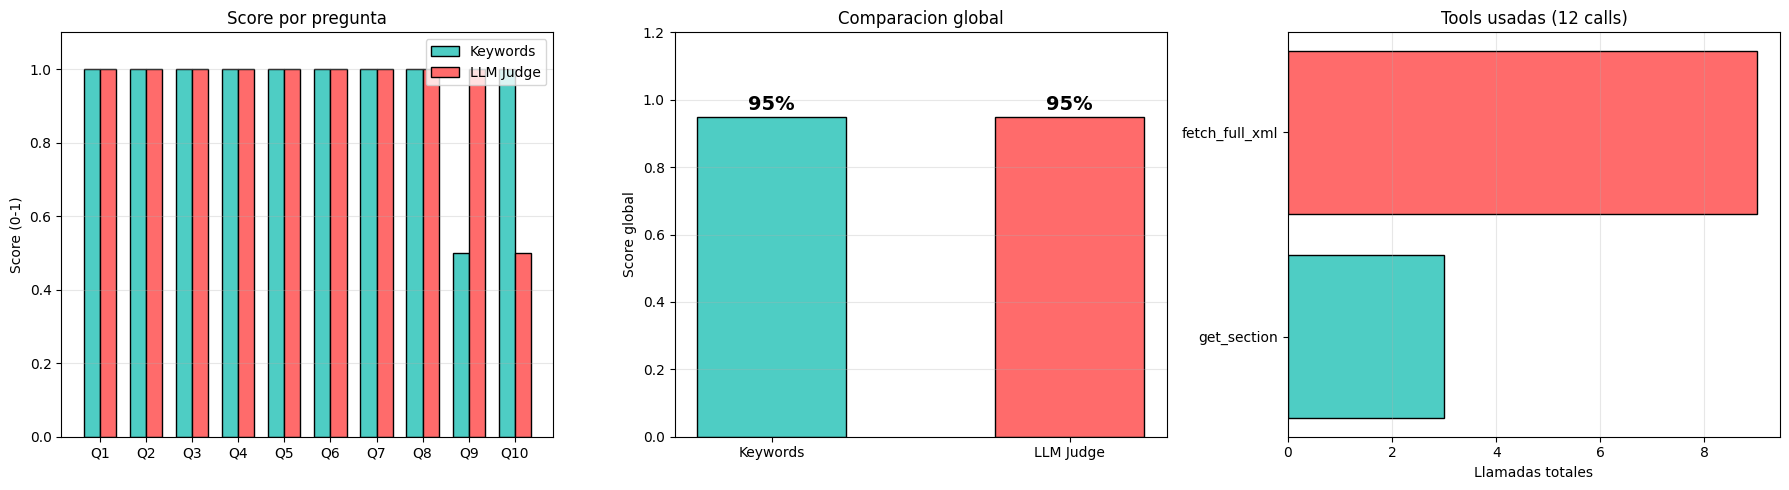


Discrepancias entre Keywords y LLM Judge:
------------------------------------------------------------
  Q9: Keywords=PARTIAL, Judge=PASS
        Juez: La respuesta del agente identifica correctamente tanto el mercado objetivo en dólares como la cantidad de pacientes elegibles por año, coincidiendo exactamente con la respuesta esperada.
  Q10: Keywords=PASS, Judge=PARTIAL
        Juez: La respuesta del agente identifica correctamente las tecnologías futuras mencionadas, pero el razonamiento es un poco redundante al repetir información y no ser completamente conciso.


In [58]:
# ══════════════════════════════════════════════════════════════════════
# VISUALIZACION — NO MODIFICAR
# ══════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
questions_short = [f"Q{i+1}" for i in range(len(BENCHMARK))]

# Panel 1: Scores por pregunta
kw_scores = [r["kw_score"] for r in keyword_results["results"]]
judge_scores = [r["judge_score"] / 2 for r in judge_results["results"]]
x = np.arange(len(questions_short))
width = 0.35
axes[0].bar(x - width/2, kw_scores, width, label="Keywords", color="#4ECDC4", edgecolor="black")
axes[0].bar(x + width/2, judge_scores, width, label="LLM Judge", color="#FF6B6B", edgecolor="black")
axes[0].set_xticks(x)
axes[0].set_xticklabels(questions_short)
axes[0].set_ylabel("Score (0-1)")
axes[0].set_title("Score por pregunta")
axes[0].legend()
axes[0].set_ylim(0, 1.1)
axes[0].grid(True, alpha=0.3, axis="y")

# Panel 2: Score global
methods = ["Keywords", "LLM Judge"]
scores = [keyword_results["score"], judge_results["score"]]
bars = axes[1].bar(methods, scores, color=["#4ECDC4", "#FF6B6B"], edgecolor="black", width=0.5)
for bar, score in zip(bars, scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"{score:.0%}", ha="center", fontweight="bold", fontsize=14)
axes[1].set_ylabel("Score global")
axes[1].set_title("Comparacion global")
axes[1].set_ylim(0, 1.2)
axes[1].grid(True, alpha=0.3, axis="y")

# Panel 3: Tools usadas
all_calls = [call["tool"] for log in agent.tool_log for call in log]
if all_calls:
    tool_counts = Counter(all_calls)
    tools_n = list(tool_counts.keys())
    tools_c = list(tool_counts.values())
    colors = ["#4ECDC4", "#FF6B6B", "#45B7D1", "#FFA07A"]
    axes[2].barh(tools_n, tools_c, color=colors[:len(tools_n)], edgecolor="black")
    axes[2].set_xlabel("Llamadas totales")
    axes[2].set_title(f"Tools usadas ({sum(tools_c)} calls)")
    axes[2].grid(True, alpha=0.3, axis="x")
else:
    axes[2].text(0.5, 0.5, "Sin tool calls", ha="center", va="center", fontsize=14)
    axes[2].set_title("Tools usadas")

plt.tight_layout()
plt.show()

# Discrepancias
print("\nDiscrepancias entre Keywords y LLM Judge:")
print("-" * 60)
has_disc = False
for i, (kr, jr) in enumerate(zip(keyword_results["results"], judge_results["results"])):
    if kr["status"] != jr["status"]:
        has_disc = True
        print(f"  Q{i+1}: Keywords={kr['status']}, Judge={jr['status']}")
        print(f"        Juez: {jr['judge_reason']}")
if not has_disc:
    print("  (Ninguna discrepancia)")

---

## Ejercicio 5: Analizar, refinar, re-evaluar

Mira los resultados del benchmark. Si hay preguntas con FAIL o PARTIAL:

1. **Diagnostica**: mira que tools uso el agente (o si no uso ninguna). El problema esta en las descripciones de las tools, en el system prompt, o en ambos?
2. **Refina**: volve a las celdas del Ejercicio 1 y/o 2 y modifica las descripciones o el prompt
3. **Re-evalua**: volve a correr las celdas del Ejercicio 3 y 4 para ver si mejoro

Podes repetir este ciclo cuantas veces quieras.

> Este loop de **evaluar → analizar → refinar → re-evaluar** es el flujo real
> de trabajo cuando se desarrollan agentes con LLMs.

---

## Ejercicio 5b: Comparar modelos — flash-lite vs flash

Hasta ahora usaste `gemini-2.5-flash-lite` (mas rapido y barato).
Ahora vas a correr **el mismo agente con el mismo prompt y tools** pero usando `gemini-2.5-flash`
(mas capaz pero mas lento/caro) y comparar los resultados.

> Esto te permite medir cuanto impacta la eleccion del modelo
> manteniendo todo lo demas igual (prompt, tools, benchmark).

In [59]:
# Crear agente con gemini-2.5-flash (el modelo mas capaz)
agent_flash = ToolAgent(
    system_prompt=SYSTEM_PROMPT,
    tool_declarations=TOOL_DECLARATIONS,
    model_name="gemini-2.5-flash",  # modelo mas capaz
)

# Correr el mismo benchmark
agent_flash.tool_log = []
print("\n>>> Corriendo benchmark con gemini-2.5-flash...\n")
keyword_results_flash = run_keyword_benchmark(agent_flash, BENCHMARK)

ToolAgent inicializado con 4 tools (modelo: gemini-2.5-flash)

>>> Corriendo benchmark con gemini-2.5-flash...

BENCHMARK 1: KEYWORDS

--- Q1/10 [PASS] ---
Q: Que tipo de terapia esta desarrollando ACME para cancer de pulmon?
A: ACME está desarrollando una terapia génica dirigida específicamente a cáncer de pulmón de células no pequeñas (NSCLC). Esta terapia utiliza edición genética basada en CRISPR-Cas9 y tiene como objetivo...
Keywords: ['terapia genica', 'CRISPR-Cas9', 'NSCLC']/['terapia genica', 'CRISPR-Cas9', 'NSCLC'] (100%)
Tools: ['fetch_full_xml']

--- Q2/10 [PASS] ---
Q: Cual es la mutacion especifica que ACME esta intentando corregir?
A: ACME está intentando corregir la mutación EGFR-L858R. Este proyecto se enfoca en la edición genética basada en CRISPR-Cas9 para corregir mutaciones oncogénicas específicas en pacientes adultos con cán...
Keywords: ['EGFR-L858R']/['EGFR-L858R'] (100%)
Tools: ['fetch_full_xml']

--- Q3/10 [PASS] ---
Q: Cuantos pacientes tiene la cohorte del ens

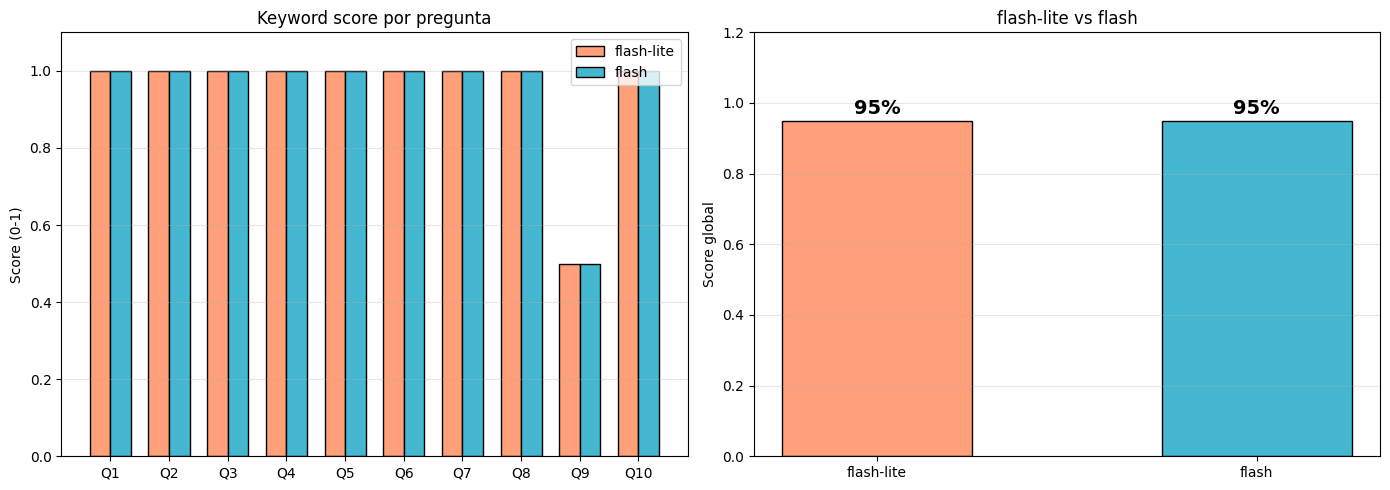


flash-lite: 95%
flash:      95%
Mismo score

Preguntas donde difieren:


In [60]:
# ── Comparacion visual: flash-lite vs flash ──────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

questions_short = [f"Q{i+1}" for i in range(len(BENCHMARK))]
x = np.arange(len(questions_short))
width = 0.35

# Panel 1: Score por pregunta
lite_scores = [r["kw_score"] for r in keyword_results["results"]]
flash_scores = [r["kw_score"] for r in keyword_results_flash["results"]]

axes[0].bar(x - width/2, lite_scores, width, label="flash-lite", color="#FFA07A", edgecolor="black")
axes[0].bar(x + width/2, flash_scores, width, label="flash", color="#45B7D1", edgecolor="black")
axes[0].set_xticks(x)
axes[0].set_xticklabels(questions_short)
axes[0].set_ylabel("Score (0-1)")
axes[0].set_title("Keyword score por pregunta")
axes[0].legend()
axes[0].set_ylim(0, 1.1)
axes[0].grid(True, alpha=0.3, axis="y")

# Panel 2: Score global
models = ["flash-lite", "flash"]
global_scores = [keyword_results["score"], keyword_results_flash["score"]]
bars = axes[1].bar(models, global_scores, color=["#FFA07A", "#45B7D1"], edgecolor="black", width=0.5)
for bar, score in zip(bars, global_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"{score:.0%}", ha="center", fontweight="bold", fontsize=14)
axes[1].set_ylabel("Score global")
axes[1].set_title("flash-lite vs flash")
axes[1].set_ylim(0, 1.2)
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# Resumen
print(f"\nflash-lite: {keyword_results['score']:.0%}")
print(f"flash:      {keyword_results_flash['score']:.0%}")
diff = keyword_results_flash['score'] - keyword_results['score']
if diff > 0:
    print(f"flash mejora en {diff:.0%}")
elif diff < 0:
    print(f"flash-lite es mejor por {-diff:.0%}")
else:
    print("Mismo score")

# Detalle de diferencias
print("\nPreguntas donde difieren:")
for i in range(len(BENCHMARK)):
    ls = keyword_results["results"][i]["status"]
    fs = keyword_results_flash["results"][i]["status"]
    if ls != fs:
        print(f"  Q{i+1}: lite={ls}, flash={fs}")

---

## Ejercicio 6: Preguntas conceptuales

Responde en las celdas de abajo.

### 6.1 — System prompt
Que instrucciones incluiste en tu system prompt? Por que elegiste esas y no otras?
Si iteraste, que cambiaste entre versiones y que efecto tuvo?

En el system prompt incluímos instrucciones orientadas a definir el rol del agente, su comportamiento y la forma en que debe utilizar las tools.

En primer lugar, establecímos el rol del agente como un asistente especializado en analizar un mind map específico, limitando explícitamente su conocimiento a esa fuente. A partir de eso, incorporamos como regla principal que debe usar siempre las tools para obtener información y que no puede inventar datos ni completar con conocimiento propio, para garantizar respuestas confiables.

Luego, agregamos instrucciones claras sobre el uso de cada tool, indicando en qué casos corresponde usar `list_sections`, `get_section`, `fetch_full_xml` y `calculate`. Esto ayuda al modelo a tomar mejores decisiones al usarlas.

Una parte importante del prompt fue definir una estrategia de búsqueda. Inicialmente intenté que el agente explorara distintas secciones usando `list_sections` y `get_section`, pero en la práctica esto no funcionó bien porque el agente no realizaba múltiples llamadas a tools. Por este motivo, modificamos la estrategia para priorizar el uso de `fetch_full_xml` cuando no es evidente en qué sección se encuentra la información. Este cambio mejoró el output, ya que le permite acceder a todo el contenido en una sola llamada, aunque no es lo más eficiente.

También incluímos reglas de formato, como responder de manera clara, directa y sin mencionar el uso de tools, para mejorar la calidad con el usuario.

En cuanto a la iteración, al principio el agente tendía a no responder o a pedirle al usuario que eligiera una sección. Luego ajustamos el prompt agregando reglas más estrictas (por ejemplo, “siempre dar una respuesta” y “no delegar decisiones al usuario”). Esto permitió que el agente pase de fallar en preguntas abiertas a responder correctamente.

### 6.2 — Tool descriptions
Cual fue la descripcion mas dificil de escribir? Hubo alguna tool que el agente no usaba
hasta que mejoraste su descripcion? Que aprendiste sobre como el LLM interpreta las descripciones?

La descripción más difícil de escribir fue la de `get_section`, porque el modelo tenía que entender que no siempre iba a haber una coincidencia exacta entre lo que preguntaba el usuario y el nombre de la sección.

Sí, hubo tools que al principio el agente no usaba bien, especialmente `get_section`. Después de mejorar la descripción (agregando ejemplos de secciones y cuándo usarla o no usarla), empezó a elegirla mejor.

Aprendimos que el LLM interpreta las descripciones como “pistas de decisión”. Si la descripción es muy vaga, no sabe cuándo usar la tool. Pero si le das ejemplos concretos, mejora mucho la selección.

### 6.3 — Keywords vs LLM-as-a-Judge
Hubo discrepancias entre los dos metodos de evaluacion? Cual te parece mas justo y por que?
Que ventajas y desventajas tiene cada uno?

Sí, hubo discrepancias. A veces el método de keywords marcaba como incorrecta una respuesta que en realidad estaba bien formulada pero con palabras distintas. En cambio, el LLM-as-a-Judge era más flexible y entendía mejor el significado.

Nos parece más justo el LLM-as-a-Judge porque evalúa semánticamente y no solo por coincidencia exacta. Pero también tiene desventajas porque puede ser más subjetivo.

Por ejemploo,

Con keywords, para la Q9 nos marcaba partial:

--- Q9/10 [PARTIAL] ---
Q: Cual es el mercado objetivo en dolares y cuantos pacientes son elegibles por anio?
A: El mercado objetivo es de $18 mil millones de USD y hay 2.1 millones de pacientes elegibles por año.
Keywords: ['18']/['18', '2.1M'] (50%)
Tools: ['fetch_full_xml']

Con LLM-as-a-Judge nos marcaba pass:

--- Q9/10 [PASS] (score=2/2) ---
Q: Cual es el mercado objetivo en dolares y cuantos pacientes son elegibles por anio?
A: El mercado objetivo es de $18 mil millones de USD y hay 2.1 millones de pacientes elegibles por año.
Juez: La respuesta del agente coincide exactamente con la información esperada, proporcionando el tamaño del mercado objetivo en dólares y el número de pacientes elegibles por año.

Con Q9 lo que pasaba es que en la respuesta decía '2.1 millones' en vez de '2.1M', y lo toma mal.

### 6.4 — RAG Tool-Use vs RAG vectorial
Cuando conviene usar cada enfoque? En que escenarios tool-use es claramente mejor?
Y en cuales RAG seria preferible?

El tool-use conviene cuando tenés estructuras claras como este caso (un mind map con secciones), donde sabés exactamente cómo acceder a la información.

En cambio, el RAG vectorial es mejor cuando tenés mucho texto desordenado o documentos largos donde no sabés exactamente dónde está la información. En este enfoque, la búsqueda se hace mediante embeddings, es decir, representaciones vectoriales del texto que permiten encontrar contenido similar en términos de significado.

Tool-use es mejor cuando hay funciones bien definidas (como cálculos o secciones específicas). RAG es preferible cuando necesitás buscar por similitud semántica en grandes volúmenes de texto.

### 6.5 — flash-lite vs flash
Que diferencias observaste entre los dos modelos? Hubo preguntas donde uno fallo y el otro no?
En que casos justificaria usar el modelo mas caro? Y en cuales el lite es suficiente?

En nuestro caso no observamos diferencias entre los modelos flash-lite y flash, ya que ambos obtuvieron el mismo score (95%) en el benchmark.

El único caso parcial fue en la pregunta sobre el mercado objetivo y los pacientes elegibles por año. Si bien la respuesta del agente incluía correctamente ambos datos (18 mil millones USD y 2.1 millones de pacientes), el método de evaluación por keywords solo detectó uno de ellos, lo que resultó en un score parcial.

Sin embargo, se pueden observar algunas diferencias como que el modelo flash tendió a dar respuestas un poco más completas y mejor redactadas, agregando más contexto. En cambio, flash-lite respondió de forma más directa.